# Ridge Regression/Regularisation


When there are chances of Overfitting, we need to introduce Regularisation.

Kinds:

1) Ridge (L2)
2) Lasso (L1)
3) Elastic Net

Note that in the case of Overfitting, usually the value of m (the slope) is high, which means we are highly dependent on x to find y, similarly, when m is very low, the model is usually underfitting.

We add a term (lambda*m^2) to the loss function, where m is the slope.

L2 come from the m^2 term referring to the L2 Norm.

## Lets work on some data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

In [3]:
data = load_diabetes()

In [4]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [5]:
X = data.data
y = data.target

In [6]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

In [8]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [9]:
lr.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = lr.predict(X_test)

In [11]:
from sklearn.metrics import r2_score, mean_squared_error
print("R2 score: ", r2_score(y_test, y_pred))
print("RMSE score: ", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 score:  0.5188113124539246
RMSE score:  48.727137609532534


In [14]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=0.0001) # this alpha is the lambda we talked about
R.fit(X_train, y_train)

Ridge(alpha=0.0001)

In [15]:
y_pred1 = R.predict(X_test)

print("R2 score: ", r2_score(y_test, y_pred1))
print("RMSE score: ", np.sqrt(mean_squared_error(y_test, y_pred1)))

R2 score:  0.5189732635884952
RMSE score:  48.71893700181955


It performed almost same as the linear Regression. Note that the alpha = 0 means we are performing Linear Regression

A too high value of alpha will lead to underfitting, means we are reducing the weight of slope a lot. Zero value corresponds to the linear model we have made, usually overfitted, the reason we are introducing Ridge Regression.

Lets see all of this in practical using a fake data

## Impact of Aplhas

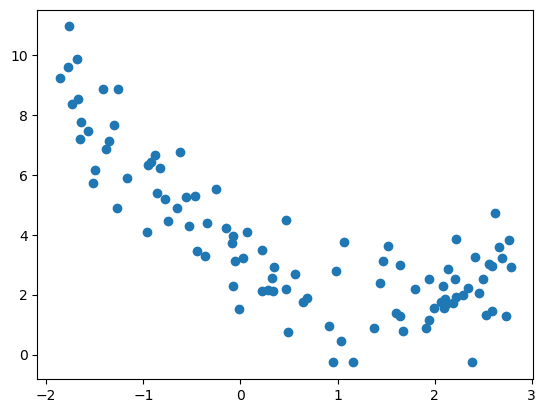

In [18]:
m = 100 # Number of data points
x1 = 5 * np.random.rand(m,1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m,1)

plt.scatter(x1, x2)
plt.show()

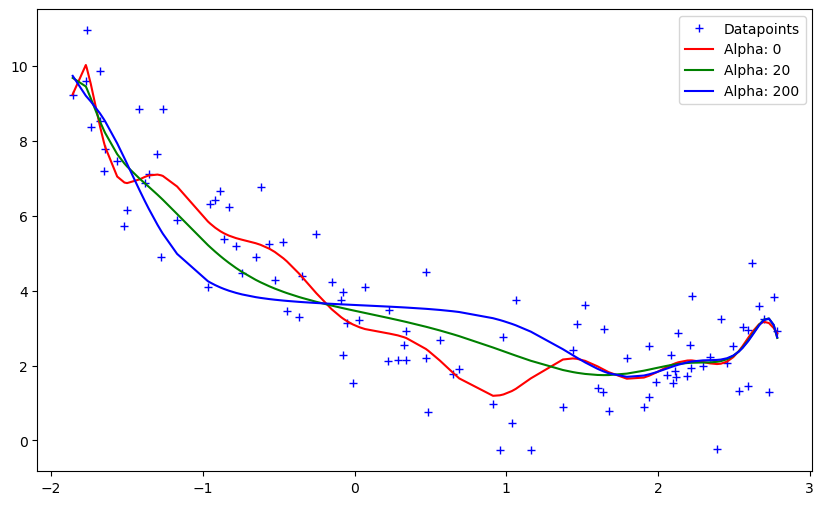

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)), # applying a degree 16 polynomial Regression for Overfitting
        ('ridge', Ridge(alpha = alpha)) # Using Ridge Regreesion instead of Linear Regression 
    ])
    model.fit(x1,x2)
    return model.predict(x1)

alphas = [0, 20, 200] # 0 -> Linear Regression, 20 -> a good choice, 200-> high value will lead to underfititng, this will reduce the weight of m a lot
cs = ['r', 'g', 'b'] # Colors to represent all the three cases

plt.figure(figsize=(10,6))
plt.plot(x1, x2, 'b+', label = 'Datapoints')

for alpha, c in zip(alphas , cs): # zip pairs elements from multiple iterables(here the alphas and the colors)
    preds = get_preds_ridge(x1, x2, alpha)
    # Lets plot each individual case
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label = f'Alpha: {alpha}')

plt.legend()
plt.show()

What are the Results?

1) Alpha = 0 : The red line is clearly as overfit for the training data, as we have used a degree 16 polynomail features model.
2) Alpha = 20 : The Green line seems like an optimum solution to this problem
3) Alpha = 200 : The Blue Lines seems to be underfitting to the training data.

### Why did we do this Sorting Thingy?

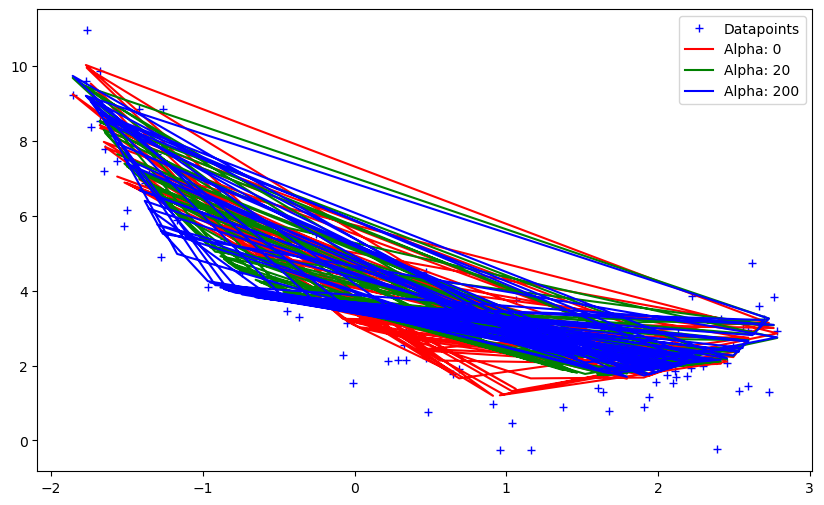

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)), # applying a degree 16 polynomial Regression for Overfitting
        ('ridge', Ridge(alpha = alpha)) # Using Ridge Regreesion instead of Linear Regression 
    ])
    model.fit(x1,x2)
    return model.predict(x1)

alphas = [0, 20, 200] # 0 -> Linear Regression, 20 -> a good choice, 200-> high value will lead to underfititng, this will reduce the weight of m a lot
cs = ['r', 'g', 'b'] # Colors to represent all the three cases

plt.figure(figsize=(10,6))
plt.plot(x1, x2, 'b+', label = 'Datapoints')

for alpha, c in zip(alphas , cs): # zip pairs elements from multiple iterables(here the alphas and the colors)
    preds = get_preds_ridge(x1, x2, alpha)
    # Lets plot each individual case
    plt.plot(x1, preds, c, label = f'Alpha: {alpha}')

plt.legend()
plt.show()

For a smooth plot, as the data points in x1 are not increasing or decresingly spread.

arg sort returns the index of where a element is in the sorted order